#Unzipping the Devnagri zip file

In [ ]:
import zipfile
import os

# Define paths
path_to_zip_file = '/content/drive/MyDrive/AI and Machine Learning/Workshop_4/Copy of devnagari digit.zip'
directory_to_extract_to = '/content/drive/MyDrive/AI and Machine Learning/Workshop_4/'

# Create the destination directory if it doesn't exist
os.makedirs(directory_to_extract_to, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
    zip_ref.extractall(directory_to_extract_to)

#Preparation of Data

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

training_path = "/content/drive/MyDrive/AI and Machine Learning/Workshop_4/DevanagariHandwrittenDigitDataset/Train"
testing_path  = "/content/drive/MyDrive/AI and Machine Learning/Workshop_4/DevanagariHandwrittenDigitDataset/Test"

image_dimensions = (28, 28)
number_of_classes = 10

In [3]:
def load_data(directory):
    img_list, lbl_list = [], []
    categories = sorted(os.listdir(directory))
    label_index = {name: idx for idx, name in enumerate(categories)}

    for category in categories:
        category_path = os.path.join(directory, category)
        if not os.path.isdir(category_path):
            continue
        for file in os.listdir(category_path):
            file_path = os.path.join(category_path, file)
            try:
                image = Image.open(file_path).convert("L")
                image = image.resize(image_dimensions)
                image_array = np.array(image) / 255.0
                img_list.append(image_array)
                lbl_list.append(label_index[category])
            except Exception:
                pass

    return np.array(img_list), np.array(lbl_list)

x_train_raw, y_train_raw = load_data(training_path)
x_test_raw,  y_test_raw  = load_data(testing_path)

x_train = x_train_raw.reshape(-1, 28 * 28)
x_test  = x_test_raw.reshape(-1, 28 * 28)

y_train = to_categorical(y_train_raw, number_of_classes)
y_test  = to_categorical(y_test_raw,  number_of_classes)

print(f"Train: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test : {x_test.shape},  Labels: {y_test.shape}")

Train: (17000, 784), Labels: (17000, 10)
Test : (3000, 784),  Labels: (3000, 10)


#Visualizing Sample Images

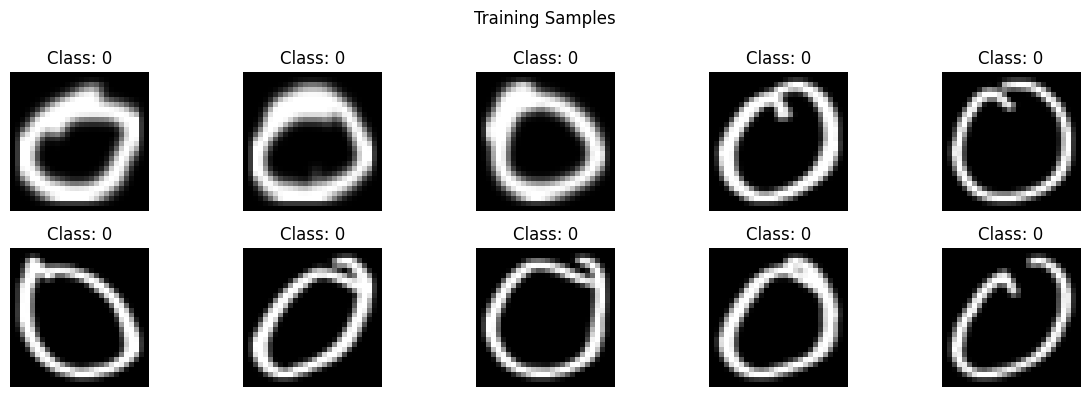

In [4]:
plt.figure(figsize=(12, 4))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_train_raw[idx], cmap='gray')
    plt.title(f"Class: {y_train_raw[idx]}")
    plt.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

#FCN MODEL

In [5]:
neural_net = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64,  activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(number_of_classes, activation='softmax')
])

neural_net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
neural_net.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
training_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        verbose=1
    )
]

training_history = neural_net.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=training_callbacks,
    verbose=1
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2612 - loss: 2.0148
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4526 - loss: 1.6857 - val_accuracy: 0.0000e+00 - val_loss: 8.4180
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8155 - loss: 0.7000
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8504 - loss: 0.5500 - val_accuracy: 0.0000e+00 - val_loss: 9.9098
Epoch 3/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9225 - loss: 0.3046
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9294 - loss: 0.2646 - val_accuracy: 0.0000e+00 - val_loss: 10.7618
Epoch 4/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9456 - loss: 0.1990
Epoch 4: val_accuracy did not im

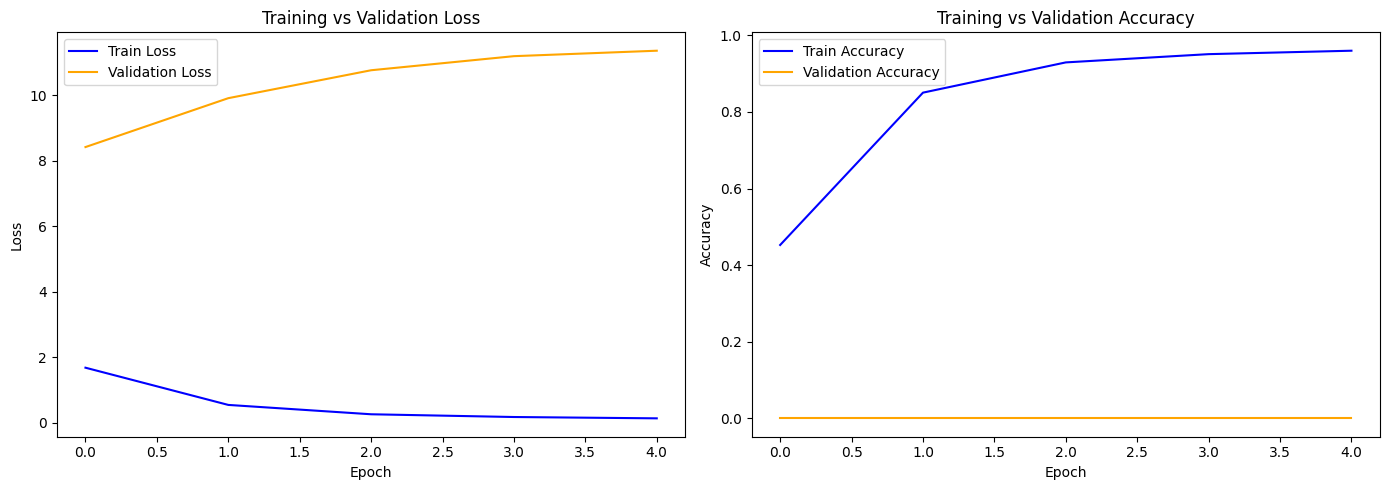

In [8]:
fig, plot_axes = plt.subplots(1, 2, figsize=(14, 5))

plot_axes[0].plot(training_history.history['loss'], label='Train Loss', color='blue')
plot_axes[0].plot(training_history.history['val_loss'], label='Validation Loss', color='orange')
plot_axes[0].set_title('Training vs Validation Loss')
plot_axes[0].set_xlabel('Epoch')
plot_axes[0].set_ylabel('Loss')
plot_axes[0].legend()

plot_axes[1].plot(training_history.history['accuracy'], label='Train Accuracy', color='blue')
plot_axes[1].plot(training_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plot_axes[1].set_title('Training vs Validation Accuracy')
plot_axes[1].set_xlabel('Epoch')
plot_axes[1].set_ylabel('Accuracy')
plot_axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
evaluation_loss, evaluation_accuracy = neural_net.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Loss    : {evaluation_loss:.4f}")
print(f"Test Accuracy: {evaluation_accuracy:.4f} ({evaluation_accuracy*100:.2f}%)")

94/94 - 0s - 2ms/step - accuracy: 0.7603 - loss: 2.4023

Test Loss    : 2.4023
Test Accuracy: 0.7603 (76.03%)


In [11]:
neural_net.save('devnagari_fcn_model.h5')
print("Model saved → devnagari_fcn_model.h5")

reloaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
reloaded_loss, reloaded_accuracy = reloaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model — Test Loss: {reloaded_loss:.4f}, Test Accuracy: {reloaded_accuracy:.4f}")

Model saved → devnagari_fcn_model.h5
94/94 - 1s - 10ms/step - accuracy: 0.7603 - loss: 2.4023

Loaded Model — Test Loss: 2.4023, Test Accuracy: 0.7603


In [12]:
test_predictions = reloaded_model.predict(x_test)
predicted_classes = np.argmax(test_predictions, axis=1)
actual_classes = np.argmax(y_test, axis=1)

print(f"Predicted: {predicted_classes[:10]}")
print(f"True     : {actual_classes[:10]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
True     : [0 0 0 0 0 0 0 0 0 0]


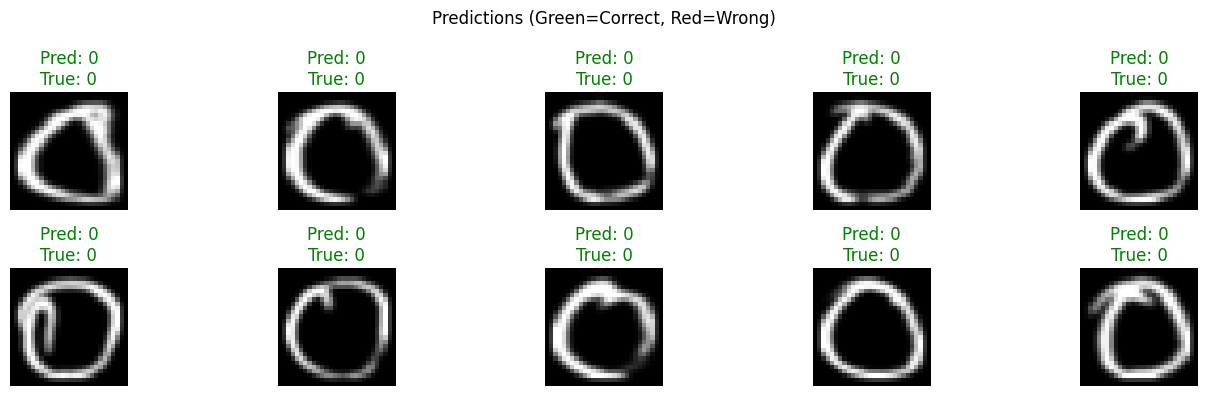

In [13]:
plt.figure(figsize=(14, 4))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_test_raw[idx], cmap='gray')
    color = 'green' if predicted_classes[idx] == actual_classes[idx] else 'red'
    plt.title(f"Pred: {predicted_classes[idx]}\nTrue: {actual_classes[idx]}", color=color)
    plt.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()